<a href="https://colab.research.google.com/github/Shah-Shawon/Deep-Learing-Assignments/blob/main/DL_Assignment_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q torch torchvision matplotlib seaborn scikit-learn

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import os
import warnings
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
os.makedirs("output", exist_ok=True)

Device: cuda


In [ ]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

full_train = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

train_size = 40000
val_size = 10000
trainset, valset = random_split(full_train, [train_size, val_size])

testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)
print("Train size:", len(trainset))
print("Val size:", len(valset))
print("Test size:", len(testset))

100%|██████████| 170M/170M [00:15<00:00, 11.1MB/s]


Train size: 40000
Val size: 10000
Test size: 10000


In [ ]:
trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=128, shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print("Classes:", classes)

Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [12]:
def train_one_model(model, trainloader, valloader, epochs=10, lr=0.001, weight_decay=0.0, label="model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        total_train, correct_train, running_loss = 0, 0, 0.0

        for x, y in trainloader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = out.argmax(1)
            total_train += y.size(0)
            correct_train += (preds == y).sum().item()

        train_loss = running_loss / len(trainloader)
        train_acc = 100 * correct_train / total_train

        model.eval()
        total_val, correct_val, val_running_loss = 0, 0, 0.0
        with torch.no_grad():
            for x, y in valloader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                val_running_loss += loss.item()

                preds = out.argmax(1)
                total_val += y.size(0)
                correct_val += (preds == y).sum().item()

        val_loss = val_running_loss / len(valloader)
        val_acc = 100 * correct_val / total_val

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"{label} | Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return model, train_losses, val_losses, train_accs, val_accs


def test_model(model, testloader):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for x, y in testloader:
            x = x.to(device)
            out = model(x)
            preds = out.argmax(1).cpu().numpy()
            y_true.extend(y.numpy())
            y_pred.extend(preds)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_true, y_pred


def plot_curves(results, title_prefix):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for name, r in results.items():
        epochs_for_model = range(1, len(r['train_losses']) + 1) # Dynamically set epochs for each model
        plt.plot(epochs_for_model, r['train_losses'], label=f"{name} Train")
        plt.plot(epochs_for_model, r['val_losses'], linestyle='--', label=f"{name} Val")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss Curves")
    plt.legend()

    plt.subplot(1, 2, 2)
    for name, r in results.items():
        epochs_for_model = range(1, len(r['train_accs']) + 1) # Dynamically set epochs for each model
        plt.plot(epochs_for_model, r['train_accs'], label=f"{name} Train")
        plt.plot(epochs_for_model, r['val_accs'], linestyle='--', label=f"{name} Val")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title(f"{title_prefix} Accuracy Curves")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"output/{title_prefix.lower().replace(' ', '_')}_curves.png", dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
class UnderfitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(3, 8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(8 * 16 * 16, 10)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

print("UnderfitCNN parameters:", sum(p.numel() for p in UnderfitCNN().parameters()))

underfit_model, underfit_train_losses, underfit_val_losses, underfit_train_accs, underfit_val_accs = train_one_model(
    UnderfitCNN(), trainloader, valloader, epochs=5, lr=0.001, label="Underfit"
)

underfit_test_acc, y_true_u, y_pred_u = test_model(underfit_model, testloader)
print("Underfitting Test Accuracy:", underfit_test_acc * 100)
print(classification_report(y_true_u, y_pred_u, target_names=classes))

UnderfitCNN parameters: 20714
Underfit | Epoch 1/5 | Train Loss: 1.7687 | Train Acc: 37.28% | Val Loss: 1.6353 | Val Acc: 40.98%
Underfit | Epoch 2/5 | Train Loss: 1.5671 | Train Acc: 44.49% | Val Loss: 1.5284 | Val Acc: 46.01%
Underfit | Epoch 3/5 | Train Loss: 1.5148 | Train Acc: 45.85% | Val Loss: 1.4921 | Val Acc: 47.48%
Underfit | Epoch 4/5 | Train Loss: 1.4868 | Train Acc: 47.01% | Val Loss: 1.4870 | Val Acc: 47.32%
Underfit | Epoch 5/5 | Train Loss: 1.4732 | Train Acc: 47.43% | Val Loss: 1.4612 | Val Acc: 47.83%
Underfitting Test Accuracy: 52.27
              precision    recall  f1-score   support

       plane       0.53      0.62      0.57      1000
         car       0.59      0.66      0.62      1000
        bird       0.43      0.34      0.38      1000
         cat       0.40      0.37      0.39      1000
        deer       0.48      0.38      0.42      1000
         dog       0.51      0.40      0.45      1000
        frog       0.53      0.66      0.59      1000
       h

In [ ]:
class OverfitCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("OverfitCNN parameters:", sum(p.numel() for p in OverfitCNN().parameters()))

overfit_model, overfit_train_losses, overfit_val_losses, overfit_train_accs, overfit_val_accs = train_one_model(
    OverfitCNN(), trainloader, valloader, epochs=20, lr=0.001, label="Overfit"
)

overfit_test_acc, y_true_o, y_pred_o = test_model(overfit_model, testloader)
print("Overfitting Test Accuracy:", overfit_test_acc * 100)
print(classification_report(y_true_o, y_pred_o, target_names=classes))

OverfitCNN parameters: 13420426
Overfit | Epoch 1/20 | Train Loss: 1.8489 | Train Acc: 29.05% | Val Loss: 1.6223 | Val Acc: 38.30%
Overfit | Epoch 2/20 | Train Loss: 1.3428 | Train Acc: 50.11% | Val Loss: 1.1466 | Val Acc: 58.29%
Overfit | Epoch 3/20 | Train Loss: 1.0651 | Train Acc: 61.57% | Val Loss: 0.9784 | Val Acc: 64.13%
Overfit | Epoch 4/20 | Train Loss: 0.8932 | Train Acc: 68.31% | Val Loss: 0.9245 | Val Acc: 67.29%
Overfit | Epoch 5/20 | Train Loss: 0.7687 | Train Acc: 73.02% | Val Loss: 0.7805 | Val Acc: 73.47%
Overfit | Epoch 6/20 | Train Loss: 0.6694 | Train Acc: 76.69% | Val Loss: 0.7181 | Val Acc: 75.52%
Overfit | Epoch 7/20 | Train Loss: 0.6089 | Train Acc: 78.75% | Val Loss: 0.6418 | Val Acc: 77.36%
Overfit | Epoch 8/20 | Train Loss: 0.5555 | Train Acc: 80.70% | Val Loss: 0.6525 | Val Acc: 77.70%
Overfit | Epoch 9/20 | Train Loss: 0.5168 | Train Acc: 82.02% | Val Loss: 0.6122 | Val Acc: 79.09%
Overfit | Epoch 10/20 | Train Loss: 0.4853 | Train Acc: 83.09% | Val Loss: 0.

In [ ]:
class RegCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("RegCNN parameters:", sum(p.numel() for p in RegCNN().parameters()))

reg_model, reg_train_losses, reg_val_losses, reg_train_accs, reg_val_accs = train_one_model(
    RegCNN(), trainloader, valloader, epochs=20, lr=0.001, weight_decay=1e-4, label="Regularized"
)

reg_test_acc, y_true_r, y_pred_r = test_model(reg_model, testloader)
print("Regularized Test Accuracy:", reg_test_acc * 100)
print(classification_report(y_true_r, y_pred_r, target_names=classes))

RegCNN parameters: 13420426
Regularized | Epoch 1/20 | Train Loss: 1.8575 | Train Acc: 29.41% | Val Loss: 1.6214 | Val Acc: 38.35%
Regularized | Epoch 2/20 | Train Loss: 1.4175 | Train Acc: 47.42% | Val Loss: 1.2264 | Val Acc: 54.15%
Regularized | Epoch 3/20 | Train Loss: 1.1549 | Train Acc: 57.97% | Val Loss: 1.0652 | Val Acc: 61.86%
Regularized | Epoch 4/20 | Train Loss: 0.9774 | Train Acc: 65.23% | Val Loss: 0.9387 | Val Acc: 66.50%
Regularized | Epoch 5/20 | Train Loss: 0.8623 | Train Acc: 69.47% | Val Loss: 0.8662 | Val Acc: 69.06%
Regularized | Epoch 6/20 | Train Loss: 0.7649 | Train Acc: 72.86% | Val Loss: 0.7729 | Val Acc: 72.86%
Regularized | Epoch 7/20 | Train Loss: 0.6932 | Train Acc: 75.75% | Val Loss: 0.7005 | Val Acc: 74.82%
Regularized | Epoch 8/20 | Train Loss: 0.6304 | Train Acc: 77.97% | Val Loss: 0.6852 | Val Acc: 76.39%
Regularized | Epoch 9/20 | Train Loss: 0.5978 | Train Acc: 79.17% | Val Loss: 0.6555 | Val Acc: 77.14%
Regularized | Epoch 10/20 | Train Loss: 0.555

In [8]:
class DropoutCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("DropoutCNN parameters:", sum(p.numel() for p in DropoutCNN().parameters()))

drop_model, drop_train_losses, drop_val_losses, drop_train_accs, drop_val_accs = train_one_model(
    DropoutCNN(), trainloader, valloader, epochs=20, lr=0.001, label="Dropout"
)

drop_test_acc, y_true_d, y_pred_d = test_model(drop_model, testloader)
print("Dropout Test Accuracy:", drop_test_acc * 100)
print(classification_report(y_true_d, y_pred_d, target_names=classes))

DropoutCNN parameters: 13420426
Dropout | Epoch 1/20 | Train Loss: 2.0613 | Train Acc: 21.49% | Val Loss: 1.9432 | Val Acc: 27.81%
Dropout | Epoch 2/20 | Train Loss: 1.8174 | Train Acc: 31.31% | Val Loss: 1.6767 | Val Acc: 38.02%
Dropout | Epoch 3/20 | Train Loss: 1.6847 | Train Acc: 37.35% | Val Loss: 1.5721 | Val Acc: 41.58%
Dropout | Epoch 4/20 | Train Loss: 1.5957 | Train Acc: 40.98% | Val Loss: 1.4948 | Val Acc: 44.92%
Dropout | Epoch 5/20 | Train Loss: 1.5295 | Train Acc: 43.63% | Val Loss: 1.4784 | Val Acc: 45.69%
Dropout | Epoch 6/20 | Train Loss: 1.4735 | Train Acc: 46.05% | Val Loss: 1.3867 | Val Acc: 48.78%
Dropout | Epoch 7/20 | Train Loss: 1.4292 | Train Acc: 47.83% | Val Loss: 1.3160 | Val Acc: 51.12%
Dropout | Epoch 8/20 | Train Loss: 1.3914 | Train Acc: 49.40% | Val Loss: 1.2337 | Val Acc: 54.76%
Dropout | Epoch 9/20 | Train Loss: 1.3630 | Train Acc: 50.66% | Val Loss: 1.2725 | Val Acc: 54.32%
Dropout | Epoch 10/20 | Train Loss: 1.3327 | Train Acc: 52.27% | Val Loss: 1.

In [9]:
class CombinedCNN(nn.Module):
    def __init__(self, dropout_p=0.5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p),

            nn.Conv2d(256, 512, 3, padding=1), nn.ReLU(),
            nn.Conv2d(512, 512, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Dropout2d(dropout_p),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 4 * 4, 1024), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(1024, 512), nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("CombinedCNN parameters:", sum(p.numel() for p in CombinedCNN().parameters()))

combined_model, combined_train_losses, combined_val_losses, combined_train_accs, combined_val_accs = train_one_model(
    CombinedCNN(), trainloader, valloader, epochs=20, lr=0.001, weight_decay=1e-4, label="Combined"
)

combined_test_acc, y_true_c, y_pred_c = test_model(combined_model, testloader)
print("Combined Test Accuracy:", combined_test_acc * 100)
print(classification_report(y_true_c, y_pred_c, target_names=classes))

CombinedCNN parameters: 13420426
Combined | Epoch 1/20 | Train Loss: 2.0396 | Train Acc: 21.94% | Val Loss: 1.8131 | Val Acc: 32.16%
Combined | Epoch 2/20 | Train Loss: 1.7849 | Train Acc: 32.83% | Val Loss: 1.5887 | Val Acc: 39.82%
Combined | Epoch 3/20 | Train Loss: 1.6448 | Train Acc: 38.49% | Val Loss: 1.4555 | Val Acc: 45.31%
Combined | Epoch 4/20 | Train Loss: 1.5423 | Train Acc: 42.84% | Val Loss: 1.3666 | Val Acc: 47.53%
Combined | Epoch 5/20 | Train Loss: 1.4585 | Train Acc: 46.44% | Val Loss: 1.2536 | Val Acc: 53.50%
Combined | Epoch 6/20 | Train Loss: 1.3924 | Train Acc: 49.33% | Val Loss: 1.2255 | Val Acc: 54.59%
Combined | Epoch 7/20 | Train Loss: 1.3461 | Train Acc: 51.42% | Val Loss: 1.1921 | Val Acc: 56.37%
Combined | Epoch 8/20 | Train Loss: 1.3160 | Train Acc: 52.39% | Val Loss: 1.1122 | Val Acc: 59.28%
Combined | Epoch 9/20 | Train Loss: 1.2740 | Train Acc: 54.35% | Val Loss: 1.0872 | Val Acc: 59.97%
Combined | Epoch 10/20 | Train Loss: 1.2495 | Train Acc: 55.08% | V

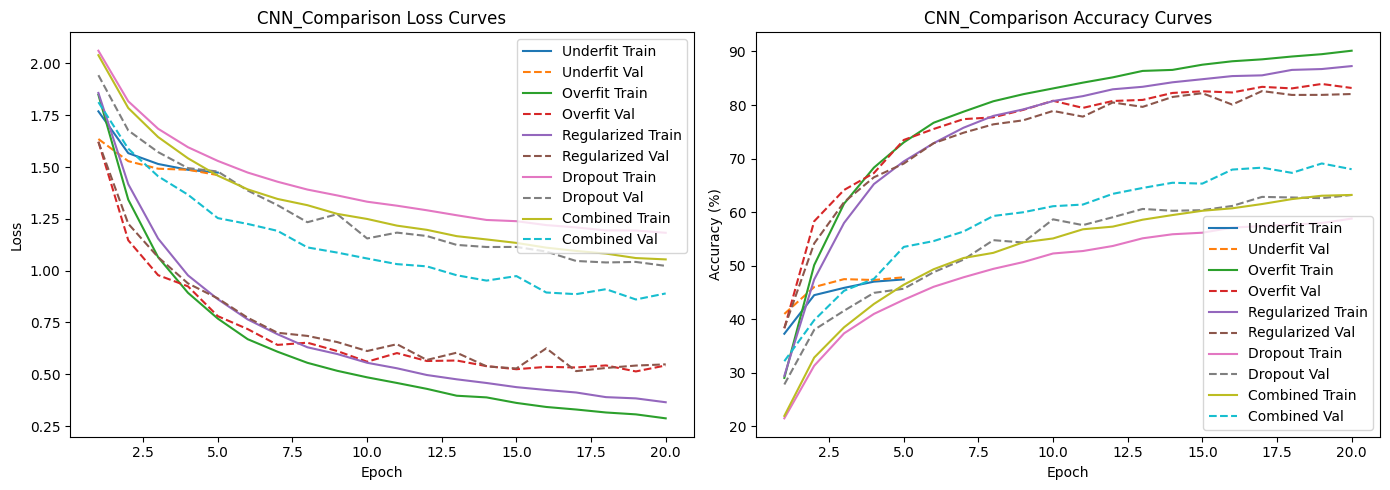

In [13]:
results = {
    "Underfit": {
        "train_losses": underfit_train_losses,
        "val_losses": underfit_val_losses,
        "train_accs": underfit_train_accs,
        "val_accs": underfit_val_accs
    },
    "Overfit": {
        "train_losses": overfit_train_losses,
        "val_losses": overfit_val_losses,
        "train_accs": overfit_train_accs,
        "val_accs": overfit_val_accs
    },
    "Regularized": {
        "train_losses": reg_train_losses,
        "val_losses": reg_val_losses,
        "train_accs": reg_train_accs,
        "val_accs": reg_val_accs
    },
    "Dropout": {
        "train_losses": drop_train_losses,
        "val_losses": drop_val_losses,
        "train_accs": drop_train_accs,
        "val_accs": drop_val_accs
    },
    "Combined": {
        "train_losses": combined_train_losses,
        "val_losses": combined_val_losses,
        "train_accs": combined_train_accs,
        "val_accs": combined_val_accs
    }
}

plot_curves(results, "CNN_Comparison")

In [15]:
summary = {
    "Model": ["Underfit", "Overfit", "Regularized", "Dropout", "Combined"],
    "Test Accuracy": [
        underfit_test_acc * 100,
        overfit_test_acc * 100,
        reg_test_acc * 100,
        drop_test_acc * 100,
        combined_test_acc * 100
    ]
}

import pandas as pd
df = pd.DataFrame(summary)
print(df)

df.to_csv("output/final_comparison.csv", index=False)
print("Saved: output/final_comparison.csv")

         Model  Test Accuracy
0     Underfit          52.27
1      Overfit          84.46
2  Regularized          83.42
3      Dropout          66.51
4     Combined          69.87
Saved: output/final_comparison.csv
